# Data Audit and EDA

Before analysing anything, every table in the database is checked for missing values, duplicate rows, and whether its ID column is actually unique. Each finding is then followed up to understand its cause, and the decision taken is recorded.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('../olist.db')

# Load every table into a dictionary so we can loop over them later
tables = {}

tables['orders'] = pd.read_sql_query("SELECT * FROM orders", conn)
tables['customers'] = pd.read_sql_query("SELECT * FROM customers", conn)
tables['order_items'] = pd.read_sql_query("SELECT * FROM order_items", conn)
tables['products'] = pd.read_sql_query("SELECT * FROM products", conn)
tables['payments'] = pd.read_sql_query("SELECT * FROM payments", conn)
tables['reviews'] = pd.read_sql_query("SELECT * FROM reviews", conn)
tables['sellers'] = pd.read_sql_query("SELECT * FROM sellers", conn)
tables['geolocation'] = pd.read_sql_query("SELECT * FROM geolocation", conn)
tables['category_translation'] = pd.read_sql_query("SELECT * FROM category_translation", conn)

conn.close()

# Print how big each table is
for name in tables:
    df = tables[name]
    print(name, "-", len(df), "rows,", len(df.columns), "columns")

orders - 99441 rows, 8 columns
customers - 99441 rows, 5 columns
order_items - 112650 rows, 7 columns
products - 32951 rows, 9 columns
payments - 103886 rows, 5 columns
reviews - 99224 rows, 7 columns
sellers - 3095 rows, 4 columns
geolocation - 1000163 rows, 5 columns
category_translation - 71 rows, 2 columns


In [2]:
# Check every table for missing values, one at a time

for name in tables:
    df = tables[name]
    
    print("=" * 60)
    print(name.upper(), "-", len(df), "rows")
    print("=" * 60)
    
    missing = df.isnull().sum()
    
    # Only show columns that actually have missing values
    missing = missing[missing > 0]
    
    if len(missing) == 0:
        print("No missing values")
    else:
        for column in missing.index:
            count = missing[column]
            percent = round(count / len(df) * 100, 2)
            print(column, ":", count, "missing (", percent, "%)")
    print()

ORDERS - 99441 rows
order_approved_at : 160 missing ( 0.16 %)
order_delivered_carrier_date : 1783 missing ( 1.79 %)
order_delivered_customer_date : 2965 missing ( 2.98 %)

CUSTOMERS - 99441 rows
No missing values

ORDER_ITEMS - 112650 rows
No missing values

PRODUCTS - 32951 rows
product_category_name : 610 missing ( 1.85 %)
product_name_lenght : 610 missing ( 1.85 %)
product_description_lenght : 610 missing ( 1.85 %)
product_photos_qty : 610 missing ( 1.85 %)
product_weight_g : 2 missing ( 0.01 %)
product_length_cm : 2 missing ( 0.01 %)
product_height_cm : 2 missing ( 0.01 %)
product_width_cm : 2 missing ( 0.01 %)

PAYMENTS - 103886 rows
No missing values

REVIEWS - 99224 rows
review_comment_title : 87656 missing ( 88.34 %)
review_comment_message : 58247 missing ( 58.7 %)

SELLERS - 3095 rows
No missing values

GEOLOCATION - 1000163 rows
No missing values

CATEGORY_TRANSLATION - 71 rows
No missing values



In [3]:
# Check for duplicate rows in each table

for name in tables:
    df = tables[name]
    duplicate_rows = df.duplicated().sum()
    print(name, ":", duplicate_rows, "duplicate rows")

print()
print("-" * 60)
print()

# Check whether each table's ID column is actually unique

print("orders - order_id unique?", tables['orders']['order_id'].nunique() == len(tables['orders']))
print("customers - customer_id unique?", tables['customers']['customer_id'].nunique() == len(tables['customers']))
print("products - product_id unique?", tables['products']['product_id'].nunique() == len(tables['products']))
print("sellers - seller_id unique?", tables['sellers']['seller_id'].nunique() == len(tables['sellers']))
print("reviews - review_id unique?", tables['reviews']['review_id'].nunique() == len(tables['reviews']))

orders : 0 duplicate rows
customers : 0 duplicate rows
order_items : 0 duplicate rows
products : 0 duplicate rows
payments : 0 duplicate rows
reviews : 0 duplicate rows
sellers : 0 duplicate rows
geolocation : 261831 duplicate rows
category_translation : 0 duplicate rows

------------------------------------------------------------

orders - order_id unique? True
customers - customer_id unique? True
products - product_id unique? True
sellers - seller_id unique? True
reviews - review_id unique? False


In [4]:
# FINDING 1: are the missing delivery dates just non-delivered orders?

orders = tables['orders']

print("Order status for orders missing a delivery date:")
missing_delivery = orders[orders['order_delivered_customer_date'].isnull()]
print(missing_delivery['order_status'].value_counts())

print()
print("Delivered orders that are STILL missing a delivery date:")
delivered = orders[orders['order_status'] == 'delivered']
print(delivered['order_delivered_customer_date'].isnull().sum())

Order status for orders missing a delivery date:
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

Delivered orders that are STILL missing a delivery date:
8


In [5]:
# FINDING 2: how bad is the review duplication?

reviews = tables['reviews']

print("Total review rows:", len(reviews))
print("Unique review_id:", reviews['review_id'].nunique())
print("Unique order_id:", reviews['order_id'].nunique())
print()
print("Orders with more than one review:",
      len(reviews) - reviews['order_id'].nunique())

Total review rows: 99224
Unique review_id: 98410
Unique order_id: 98673

Orders with more than one review: 551


In [6]:
# FINDING 3: are the 610 products missing all four fields together?

products = tables['products']

no_category = products['product_category_name'].isnull()
no_name_length = products['product_name_lenght'].isnull()

print("Missing category:", no_category.sum())
print("Missing name length:", no_name_length.sum())
print("Missing BOTH:", (no_category & no_name_length).sum())

Missing category: 610
Missing name length: 610
Missing BOTH: 610


In [7]:
# FINDING 4: do those 610 products actually get ordered?

order_items = tables['order_items']

bad_product_ids = products[no_category]['product_id']
affected = order_items[order_items['product_id'].isin(bad_product_ids)]

print("Order items involving products with no category:", len(affected))
print("As a share of all order items:",
      round(len(affected) / len(order_items) * 100, 2), "%")

Order items involving products with no category: 1603
As a share of all order items: 1.42 %


In [8]:
# FINDING 2 follow-up: why does one review_id appear on several orders?

reviews = tables['reviews']

# Count how many rows each review_id appears on
review_counts = reviews['review_id'].value_counts()

# Keep only the ones that appear more than once
repeated_reviews = review_counts[review_counts > 1]

print("Review IDs attached to more than one order:", len(repeated_reviews))
print()

# Look at one example in detail
example_id = repeated_reviews.index[0]
example_rows = reviews[reviews['review_id'] == example_id]

print("Example review_id:", example_id)
print(example_rows[['review_id', 'order_id', 'review_score']])

Review IDs attached to more than one order: 789

Example review_id: c444278834184f72b1484dfe47de7f97
                              review_id                          order_id  \
2952   c444278834184f72b1484dfe47de7f97  df56136b8031ecd28e200bb18e6ddb2e   
43897  c444278834184f72b1484dfe47de7f97  566f53fc7d36fa366f7e221468121877   
95774  c444278834184f72b1484dfe47de7f97  8557dabbdacec1a9e250f5e70afe1eab   

       review_score  
2952              5  
43897             5  
95774             5  


In [9]:
# Attach customer and purchase time to every order in a repeated review

orders = tables['orders']
customers = tables['customers']

multi = reviews[reviews['review_id'].isin(repeated_reviews.index)]

multi = multi.merge(orders[['order_id', 'customer_id', 'order_purchase_timestamp']],
                    on='order_id', how='left')
multi = multi.merge(customers[['customer_id', 'customer_unique_id']],
                    on='customer_id', how='left')

multi['order_purchase_timestamp'] = pd.to_datetime(multi['order_purchase_timestamp'])

# Question 1: how many different customers per review?
customers_per_review = multi.groupby('review_id')['customer_unique_id'].nunique()

# Question 2: how far apart were the orders, in minutes?
first_order_time = multi.groupby('review_id')['order_purchase_timestamp'].min()
last_order_time = multi.groupby('review_id')['order_purchase_timestamp'].max()
gap_minutes = (last_order_time - first_order_time).dt.total_seconds() / 60

total = len(repeated_reviews)

print("Repeated reviews checked:", total)
print()
print("All orders belong to ONE customer:", (customers_per_review == 1).sum())
print("All orders placed within 1 minute:", (gap_minutes <= 1).sum())
print("All orders placed within 24 hours:", (gap_minutes <= 1440).sum())

Repeated reviews checked: 789

All orders belong to ONE customer: 789
All orders placed within 1 minute: 730
All orders placed within 24 hours: 748


**Result:** all 789 repeated reviews belong to a single customer, and 93% of them cover
orders placed within one minute of each other. One checkout with several sellers produces
several order IDs, and the customer's single review is recorded against each. This is the
same split-basket pattern found in the SQL notebook, confirmed here from a different
direction.

## Findings and decisions

| # | Finding | Cause | Decision |
|---|---|---|---|
| 1 | 2,965 orders have no delivery date | Orders that were shipped, cancelled, unavailable, or still processing | Excluded from delivery and satisfaction analysis by filtering to delivered orders |
| 2 | 8 orders are marked delivered but have no delivery date | Inconsistent records | Excluded — no delivery outcome to measure |
| 3 | 551 orders have more than one review row | Duplicate review records | Keep only the earliest review per order |
| 4 | 789 reviews are shared across more than one order | Split baskets: one review per checkout, recorded against every order in it | Kept. Affects ~1.6% of review rows; noted as a limitation in the delivery analysis |
| 5 | 610 products missing category and all descriptive fields | Product records that were never fully populated | Labelled "unknown" in category analysis rather than dropped, since they account for 1.42% of items sold |
| 6 | 261,831 duplicate rows in geolocation | Repeated coordinates for the same zip prefix | No action — table not used |
| 7 | Review comment text missing on 59–88% of reviews | Customers leaving a score without writing anything | No action — only the numeric score is used |
| 8 | Missing approval and carrier dates on some orders | Order lifecycle stages not reached | No action — these columns are not used |

**Missing review scores are never imputed.** An order without a review is a customer who
chose not to leave one, which is different information from a low score. Filling it in
would invent opinions that don't exist.

## Tables used in this project

| Used | Why |
|---|---|
| orders | purchase and delivery dates |
| customers | links orders to people, and gives state |
| order_items | order value and item counts |
| reviews | satisfaction scores |
| sellers | seller ranking by state |
| products, category_translation | category breakdown |

| Not used | Why |
|---|---|
| geolocation | this project has no map component |
| payments | payment method and instalments aren't part of this project |

# Part 2: Exploratory Data Analysis

In [10]:
# Load the cleaned order-level table made in notebook 02
order_level = pd.read_csv('../data/order_level.csv')

# Keep only the earliest review for each order (finding 3 from the audit)
reviews_one = tables['reviews'].sort_values('review_creation_date')
reviews_one = reviews_one.drop_duplicates(subset='order_id', keep='first')

# Attach review score to each order
eda = order_level.merge(reviews_one[['order_id', 'review_score']],
                        on='order_id', how='left')

print("Rows before merge:", len(order_level))
print("Rows after merge:", len(eda))
print("Orders with no review:", eda['review_score'].isnull().sum())

Rows before merge: 96470
Rows after merge: 96470
Orders with no review: 646


Share of orders by review score (%):
review_score
1.0     9.7
2.0     3.0
3.0     8.2
4.0    19.7
5.0    59.2
Name: count, dtype: float64

Mean score: 4.16
Median score: 5.0


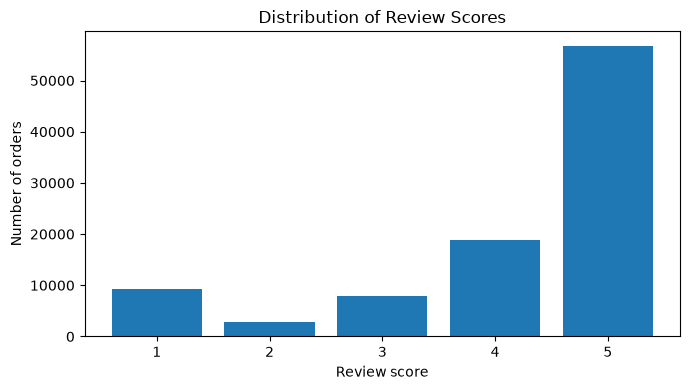

In [11]:
counts = eda['review_score'].value_counts().sort_index()
shares = (counts / counts.sum() * 100).round(1)

print("Share of orders by review score (%):")
print(shares)
print()
print("Mean score:", round(eda['review_score'].mean(), 2))
print("Median score:", eda['review_score'].median())

plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values)
plt.title('Distribution of Review Scores')
plt.xlabel('Review score')
plt.ylabel('Number of orders')
plt.tight_layout()
plt.savefig('../outputs/review_score_distribution.png', dpi=150)
plt.show()

count    96470.0
mean       -11.2
std         10.2
min       -146.0
25%        -16.2
50%        -11.9
75%         -6.4
max        189.0
Name: delivery_delay_days, dtype: float64

Arrived early (delay below 0): 91.9 %
Late by current rule (delay above 0): 8.1 %
Late by calendar day (delay 1 or more): 6.8 %

Arrived ON the promised day but after midnight: 1292 orders
More than 7 days late: 3345 orders
More than 30 days late: 360 orders


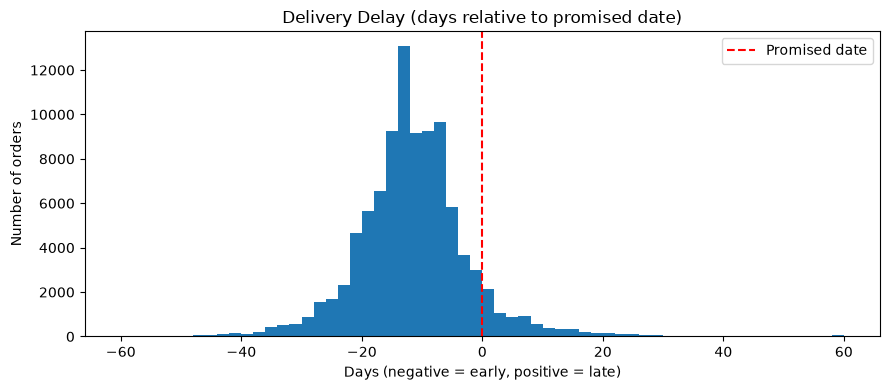

In [12]:
delay = eda['delivery_delay_days']

print(delay.describe().round(1))
print()
print("Arrived early (delay below 0):", round((delay < 0).mean() * 100, 1), "%")
print("Late by current rule (delay above 0):", round((delay > 0).mean() * 100, 1), "%")
print("Late by calendar day (delay 1 or more):", round((delay >= 1).mean() * 100, 1), "%")
print()
print("Arrived ON the promised day but after midnight:", ((delay > 0) & (delay < 1)).sum(), "orders")
print("More than 7 days late:", (delay >= 7).sum(), "orders")
print("More than 30 days late:", (delay >= 30).sum(), "orders")

plt.figure(figsize=(9, 4))
plt.hist(delay.clip(-60, 60), bins=60)
plt.axvline(0, color='red', linestyle='--', label='Promised date')
plt.title('Delivery Delay (days relative to promised date)')
plt.xlabel('Days (negative = early, positive = late)')
plt.ylabel('Number of orders')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/delivery_delay_distribution.png', dpi=150)
plt.show()

In [13]:
# The late-rule fix assumes every promised date is stored at exactly midnight.
# Check that this is true before relying on it.

promised = tables['orders']['order_estimated_delivery_date'].dropna()
not_midnight = promised[~promised.str.endswith('00:00:00')]

print("Promised dates checked:", len(promised))
print("Promised dates NOT at midnight:", len(not_midnight))

Promised dates checked: 99441
Promised dates NOT at midnight: 0


### What the distributions show

**Review scores are polarised.** 59% of orders get five stars, but one-star reviews (9.7%) are more common than two-star (3.0%) or three-star (8.2%). Customers tend to be either satisfied or angry. The mean of 4.16 hides this, so the share of 1–2 star reviews is reported alongside it in the delivery analysis.

**Olist pads its delivery promises.** The median order arrives 12 days before the promised date, and 92% arrive early. A late order has therefore overshot an already generous buffer.

**The original late definition was overstating lateness.** Promised dates are stored at midnight, so 1,292 orders delivered during the promised day were being flagged late. Using "arrived on a later calendar day" instead, the late rate is 6.8% rather than 8.1%. The definition was corrected in notebook 02.

**The late tail is long.** 3,345 orders arrived a week or more late, and 360 more than a month late. These are real orders and real bad experiences, so they are kept, not removed as outliers.

In [14]:
# Group every order by how late it arrived.
# Each bucket includes its lower edge and excludes its upper edge,
# e.g. "1-3 days late" covers delay from 1.0 up to (but not including) 4.0.

bucket_edges = [-np.inf, 0, 1, 4, 8, 15, np.inf]
bucket_names = ['Early', 'On promised day', '1-3 days late',
                '4-7 days late', '8-14 days late', '15+ days late']

eda['delay_bucket'] = pd.cut(eda['delivery_delay_days'],
                             bins=bucket_edges,
                             labels=bucket_names,
                             right=False)

bucket_counts = eda['delay_bucket'].value_counts().reindex(bucket_names)
bucket_shares = (bucket_counts / len(eda) * 100).round(2)

print("Orders in each delay bucket:")
for name in bucket_names:
    print(name, ":", bucket_counts[name], "orders (", bucket_shares[name], "%)")

print()
print("Total:", bucket_counts.sum(), "(should equal", len(eda), ")")

Orders in each delay bucket:
Early : 88644 orders ( 91.89 %)
On promised day : 1292 orders ( 1.34 %)
1-3 days late : 1870 orders ( 1.94 %)
4-7 days late : 1802 orders ( 1.87 %)
8-14 days late : 1478 orders ( 1.53 %)
15+ days late : 1384 orders ( 1.43 %)

Total: 96470 (should equal 96470 )


**Delay buckets confirmed.** Every late bucket holds between 1,384 and 1,870 orders, enough for a reliable average rating in each. The four late buckets together contain 6,534 orders, matching the 6.8% late rate. The buckets were then added to the order table in notebook 02 so the definition exists in one place.

count    96470.00
mean       137.04
std        209.05
min          0.85
25%         45.90
50%         86.50
75%        149.90
max      13440.00
Name: order_value, dtype: float64

Orders with zero or negative value: 0

90th percentile: 269.0
99th percentile: 990.0
Orders above R$1,000: 905

Revenue share from the top 10% of orders: 41.1 %

Orders containing a single item: 90.0 %

Five largest orders:
                               order_id  order_value  n_items  freight_value
1432   03caa2c082116e1d31e67e9ae3700499      13440.0        8         224.08
43479  736e1922ae60d0d6a89247b851902527       7160.0        4         114.88
3068   0812eb902a67711a1cb742b3cdaa65ae       6735.0        1         194.31
96106  fefacc66af859508bf1a7934eab1e97f       6729.0        1         193.21
92342  f5136e38d1a14a4dbd87dff67da82701       6499.0        1         227.66


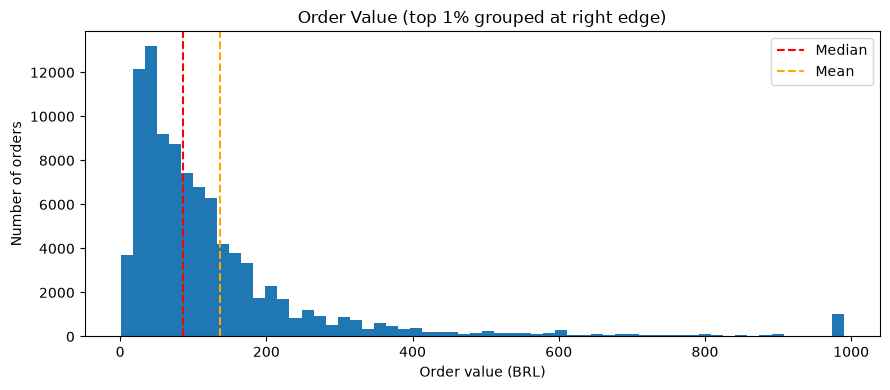

In [15]:
value = eda['order_value']

print(value.describe().round(2))
print()
print("Orders with zero or negative value:", (value <= 0).sum())
print()
print("90th percentile:", round(value.quantile(0.90), 2))
print("99th percentile:", round(value.quantile(0.99), 2))
print("Orders above R$1,000:", (value > 1000).sum())
print()

# How much revenue comes from the most expensive 10% of orders?
top_cutoff = value.quantile(0.90)
top_share = value[value >= top_cutoff].sum() / value.sum() * 100
print("Revenue share from the top 10% of orders:", round(top_share, 1), "%")
print()
print("Orders containing a single item:", round((eda['n_items'] == 1).mean() * 100, 1), "%")
print()

print("Five largest orders:")
largest = eda.sort_values('order_value', ascending=False)
print(largest[['order_id', 'order_value', 'n_items', 'freight_value']].head())

# Chart
cap = value.quantile(0.99)

plt.figure(figsize=(9, 4))
plt.hist(value.clip(upper=cap), bins=60)
plt.axvline(value.median(), color='red', linestyle='--', label='Median')
plt.axvline(value.mean(), color='orange', linestyle='--', label='Mean')
plt.title('Order Value (top 1% grouped at right edge)')
plt.xlabel('Order value (BRL)')
plt.ylabel('Number of orders')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/order_value_distribution.png', dpi=150)
plt.show()

### Order value

**No invalid values.** No order has a zero or negative value; the lowest is BRL 0.85.

**Order value is heavily skewed.** The median order is BRL 86.50 but the mean is BRL 137,
pulled up by a long tail of expensive orders reaching BRL 13,440. Average order value is
therefore reported alongside the median, since the mean alone overstates what a typical
customer spends.

**Revenue is concentrated.** The top 10% of orders account for 41% of revenue.

**Large orders were checked, not removed.** The largest orders are either multi-item baskets
or single expensive products with correspondingly high freight costs. They are real orders
and are kept.

**RFM is unaffected by the skew.** Monetary quartiles are assigned by rank, so extreme values
cannot distort the segment boundaries.

**90% of orders contain a single item.**

                orders  late_rate_pct
purchase_month                       
2016-09              1          100.0
2016-10            265            0.8
2016-12              1            0.0
2017-01            750            2.9
2017-02           1653            3.0
2017-03           2546            4.6
2017-04           2303            6.6
2017-05           3545            3.0
2017-06           3135            3.0
2017-07           3872            2.8
2017-08           4193            2.9
2017-09           4150            4.4
2017-10           4478            4.2
2017-11           7288           12.4
2017-12           5513            7.5
2018-01           7069            5.7
2018-02           6555           14.1
2018-03           7003           19.0
2018-04           6798            4.5
2018-05           6749            6.6
2018-06           6096            1.2
2018-07           6156            3.4
2018-08           6351            6.2


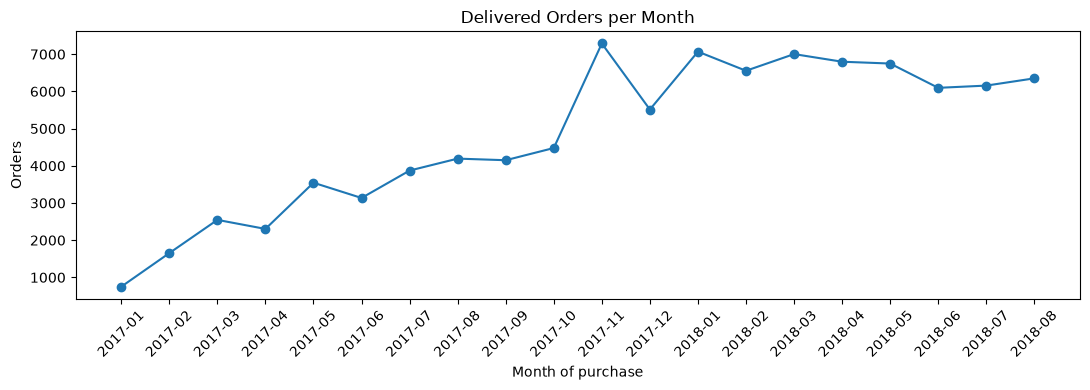

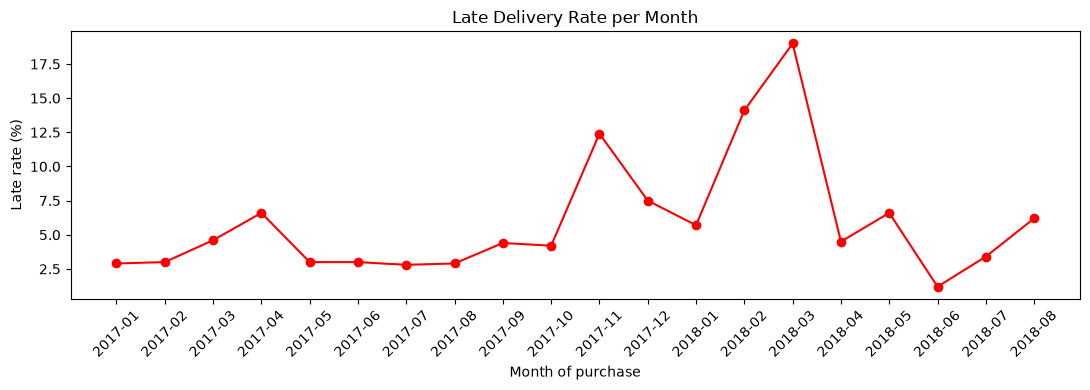

In [19]:
# Convert purchase time to a real date, then to a month
eda['order_purchase_timestamp'] = pd.to_datetime(eda['order_purchase_timestamp'])
eda['purchase_month'] = eda['order_purchase_timestamp'].dt.to_period('M')

# Orders per month, and share of them that arrived late
orders_per_month = eda.groupby('purchase_month')['order_id'].count()
late_rate_per_month = eda.groupby('purchase_month')['is_late'].mean() * 100

monthly = pd.DataFrame({
    'orders': orders_per_month,
    'late_rate_pct': late_rate_per_month.round(1)
})
print(monthly)

# Charts use Jan 2017 onwards only; 2016 is the platform's launch period with almost no orders
monthly = monthly.loc['2017-01':]

# Chart 1: order volume
plt.figure(figsize=(11, 4))
plt.plot(monthly.index.astype(str), monthly['orders'], marker='o')
plt.title('Delivered Orders per Month')
plt.xlabel('Month of purchase')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/monthly_order_volume.png', dpi=150)
plt.show()

# Chart 2: late rate
plt.figure(figsize=(11, 4))
plt.plot(monthly.index.astype(str), monthly['late_rate_pct'], marker='o', color='red')
plt.title('Late Delivery Rate per Month')
plt.xlabel('Month of purchase')
plt.ylabel('Late rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/monthly_late_rate.png', dpi=150)
plt.show()

                orders  late_rate_pct
customer_state                       
AL                 397           21.4
MA                 717           17.4
SE                 335           15.2
PI                 476           13.9
CE                1279           13.8
BA                3256           12.2
RR                  41           12.2
RJ               12350           12.1
PA                 946           11.2
ES                1995           10.7
PB                 517           10.4
TO                 274            9.9
MS                 701            9.7
PE                1593            9.6
RN                 474            9.3
SC                3546            8.2
GO                1957            6.5
RS                5344            6.1
MT                 886            6.0
DF                2080            5.7
MG               11354            4.6
SP               40494            4.5
PR                4923            4.0
AC                  80            3.8
AP          

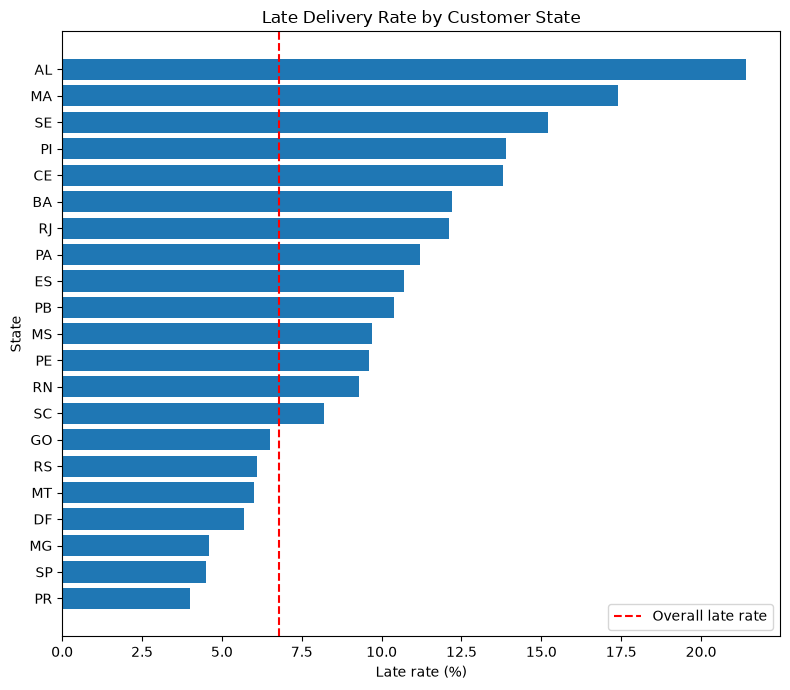

In [20]:
orders_per_state = eda.groupby('customer_state')['order_id'].count()
late_rate_per_state = eda.groupby('customer_state')['is_late'].mean() * 100

by_state = pd.DataFrame({
    'orders': orders_per_state,
    'late_rate_pct': late_rate_per_state.round(1)
})
by_state = by_state.sort_values('late_rate_pct', ascending=False)
print(by_state)

overall_late = eda['is_late'].mean() * 100

plt.figure(figsize=(8, 7))
# Chart states with at least 300 orders; smaller states have too few orders for a stable rate
by_state_plot = by_state[by_state['orders'] >= 300]
plt.barh(by_state_plot.index, by_state_plot['late_rate_pct'])
plt.axvline(overall_late, color='red', linestyle='--', label='Overall late rate')
plt.gca().invert_yaxis()
plt.title('Late Delivery Rate by Customer State')
plt.xlabel('Late rate (%)')
plt.ylabel('State')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/late_rate_by_state.png', dpi=150)
plt.show()

                orders  median_promised_days  median_actual_days  \
purchase_month                                                     
2017-01            750                  39.0                10.7   
2017-02           1653                  30.2                11.0   
2017-03           2546                  22.6                10.1   
2017-04           2303                  25.5                12.7   
2017-05           3545                  23.3                 9.8   
2017-06           3135                  23.4                10.8   
2017-07           3872                  23.0                10.2   
2017-08           4193                  22.6                 9.8   
2017-09           4150                  22.1                10.3   
2017-10           4478                  22.4                10.3   
2017-11           7288                  22.3                12.7   
2017-12           5513                  27.4                13.1   
2018-01           7069                  25.6    

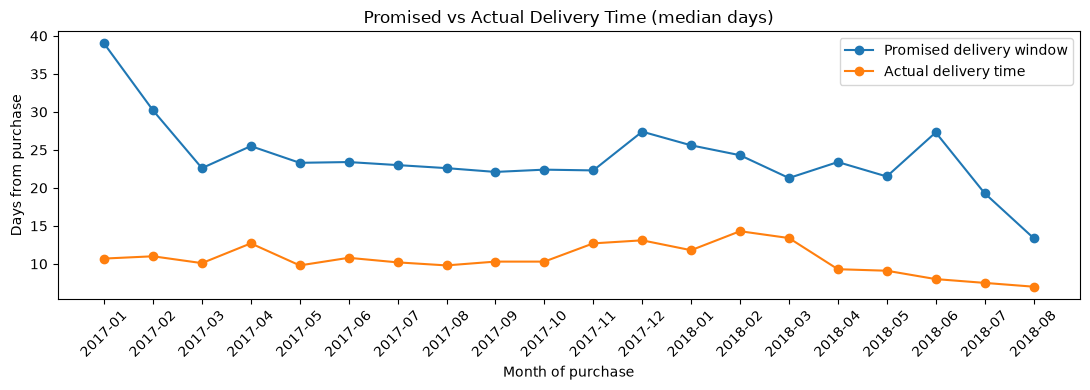

In [21]:
# Promised window = days from purchase to the promised delivery date.
# (delivered - purchased) minus (delivered - promised) = promised - purchased
eda['promised_days'] = eda['delivery_time_days'] - eda['delivery_delay_days']

promise_check = pd.DataFrame({
    'orders': eda.groupby('purchase_month')['order_id'].count(),
    'median_promised_days': eda.groupby('purchase_month')['promised_days'].median().round(1),
    'median_actual_days': eda.groupby('purchase_month')['delivery_time_days'].median().round(1),
    'late_rate_pct': (eda.groupby('purchase_month')['is_late'].mean() * 100).round(1)
})

# Keep only the usable window
promise_check = promise_check.loc['2017-01':]
print(promise_check)

plt.figure(figsize=(11, 4))
plt.plot(promise_check.index.astype(str), promise_check['median_promised_days'],
         marker='o', label='Promised delivery window')
plt.plot(promise_check.index.astype(str), promise_check['median_actual_days'],
         marker='o', label='Actual delivery time')
plt.title('Promised vs Actual Delivery Time (median days)')
plt.xlabel('Month of purchase')
plt.ylabel('Days from purchase')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/promised_vs_actual.png', dpi=150)
plt.show()

### Trends over time and by state

**Usable window: January 2017 to August 2018.** 2016 is the platform's launch period, with
almost no orders and no data at all for November 2016. The series ends in August 2018
because later orders had not yet been delivered when the data was extracted.

**Black Friday overwhelmed delivery capacity.** Order volume rose 63% in November 2017, and
the late rate tripled from 4.2% to 12.4%. The typical delivery took 12.7 days instead of
10.3, while the promised window stayed unchanged.

**The worst months had no volume surge.** February and March 2018 had the highest late rates
in the data, 14.1% and 19.0%, with normal order volume. Deliveries were genuinely slower,
with February the slowest month in the dataset at 14.3 days. In March the promised window
was also shortened by three days, so both factors worked against the customer at once. The
cause of the slowdown is not visible in this data.

**Low late rates can come from generous promises.** June 2018 had a late rate of just 1.2%,
mostly because the promised window was extended by six days.

**The late rate measures the gap between promise and delivery.** Customers are typically
promised about twice as long as delivery actually takes. The platform can reduce lateness
by delivering faster or by promising longer, and the data shows it doing both at different
times. Longer promises may make the offer less attractive, but this dataset has no browsing
or conversion data, so that trade-off cannot be measured here.

**Caution on July and August 2018.** Only delivered orders are included. Slow orders from
these months may not have arrived before the data was extracted, which would make these
months look faster than they were.

**The Northeast has the highest late rates.** Alagoas (21.4%), Maranhão (17.4%), and Sergipe
(15.2%) are far from São Paulo, where most sellers are based. Southeastern and southern
states near the sellers run around 4–5%.

**Rio de Janeiro is the largest single problem.** It is the second-largest market, with
12,350 orders, and its late rate of 12.1% is nearly three times São Paulo's 4.5%. It
accounts for roughly 23% of all late orders while making up 13% of order volume.

**States with fewer than 300 orders are excluded from the state chart.** With so few
orders, a late rate can swing widely by chance: at 300 orders the margin of error is about
±3 percentage points, at 41 orders about ±8.